# Credit Risk Prediction 


In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


## Data Cleaning

In [9]:
df = pd.read_csv('loan_dataset_20000.csv')
print("Missing values:\n", df.isnull().sum())

Missing values:
 age                     0
gender                  0
marital_status          0
education_level         0
annual_income           0
monthly_income          0
employment_status       0
debt_to_income_ratio    0
credit_score            0
loan_amount             0
loan_purpose            0
interest_rate           0
loan_term               0
installment             0
grade_subgrade          0
num_of_open_accounts    0
total_credit_limit      0
current_balance         0
delinquency_history     0
public_records          0
num_of_delinquencies    0
loan_paid_back          0
dtype: int64


In [10]:


#  Remove Duplicates
df.drop_duplicates(inplace=True)

#  Feature Engineering / Formatting

label_encoders = {}
categorical_cols = ['gender', 'marital_status', 'education_level', 
                    'employment_status', 'loan_purpose', 'grade_subgrade']

for col in categorical_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    label_encoders[col] = le  

print("\nDataset Shape after cleaning:", df.shape)
print(df.head())
df.to_csv('cleaned_loan_data.csv', index=False)


Dataset Shape after cleaning: (20000, 22)
   age  gender  marital_status  education_level  annual_income  \
0   59       1               1                2       24240.19   
1   72       0               1                0       20172.98   
2   49       0               2                1       26181.80   
3   35       0               2                1       11873.84   
4   63       2               2                3       25326.44   

   monthly_income  employment_status  debt_to_income_ratio  credit_score  \
0         2020.02                  0                 0.074           743   
1         1681.08                  0                 0.219           531   
2         2181.82                  0                 0.234           779   
3          989.49                  0                 0.264           809   
4         2110.54                  0                 0.260           663   

   loan_amount  ...  loan_term  installment  grade_subgrade  \
0     17173.72  ...         36       581

## EDA

C:\Users\User\AppData\Local\Temp\ipykernel_2468\1571365451.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='loan_paid_back', data=df, palette='Set2')


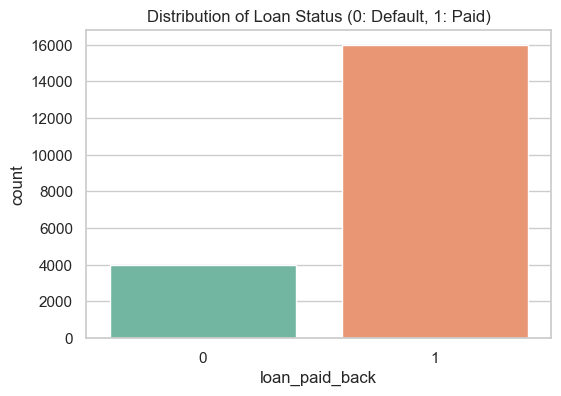

In [11]:
sns.set(style="whitegrid")

plt.figure(figsize=(6, 4))
sns.countplot(x='loan_paid_back', data=df, palette='Set2')
plt.title('Distribution of Loan Status (0: Default, 1: Paid)')
plt.show()


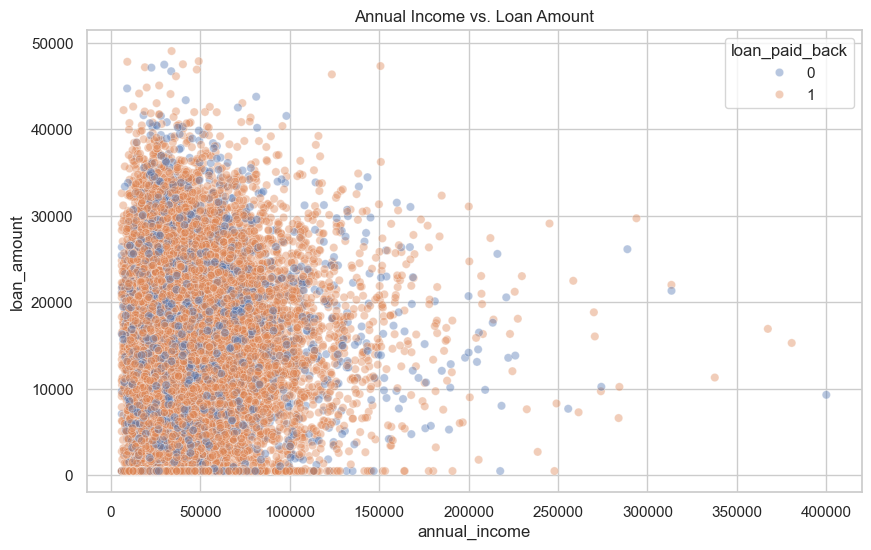

In [12]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='annual_income', y='loan_amount', hue='loan_paid_back', data=df, alpha=0.4)
plt.title('Annual Income vs. Loan Amount')
plt.show()

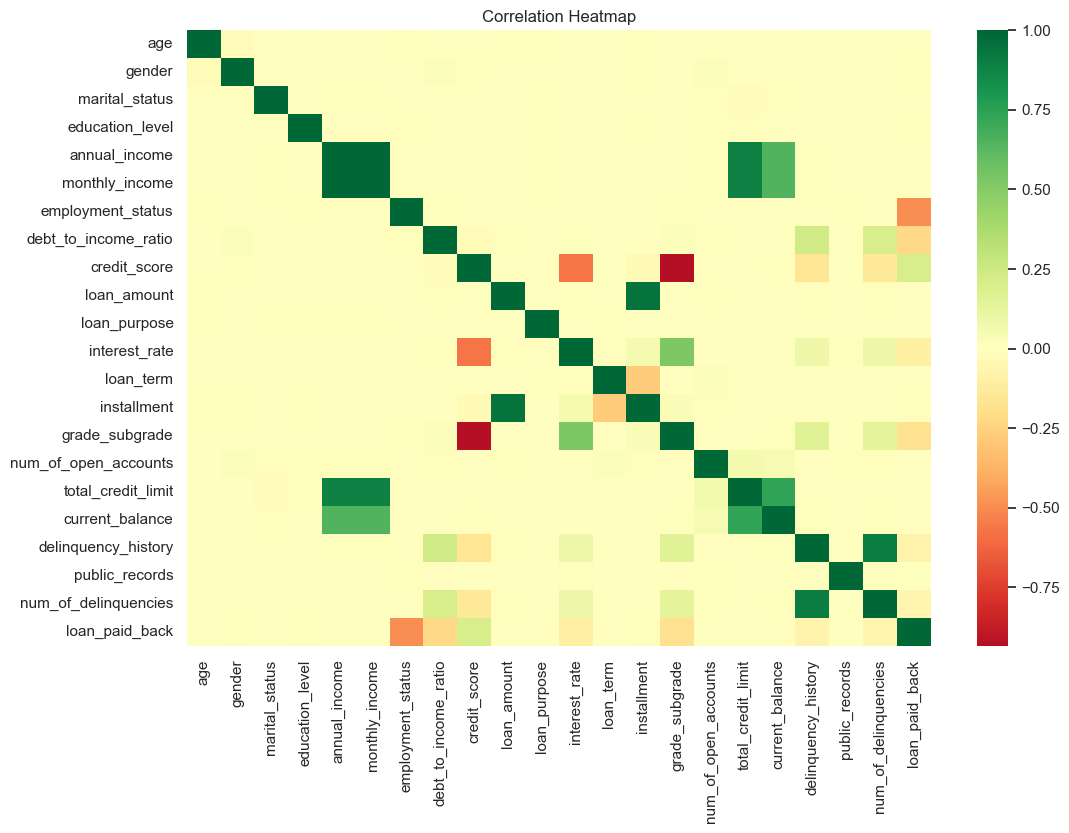

In [13]:
plt.figure(figsize=(12, 8))
numerical_cols = df.select_dtypes(include=['float64', 'int64']).columns
sns.heatmap(df[numerical_cols].corr(), annot=False, cmap='RdYlGn', center=0)
plt.title('Correlation Heatmap')
plt.show()

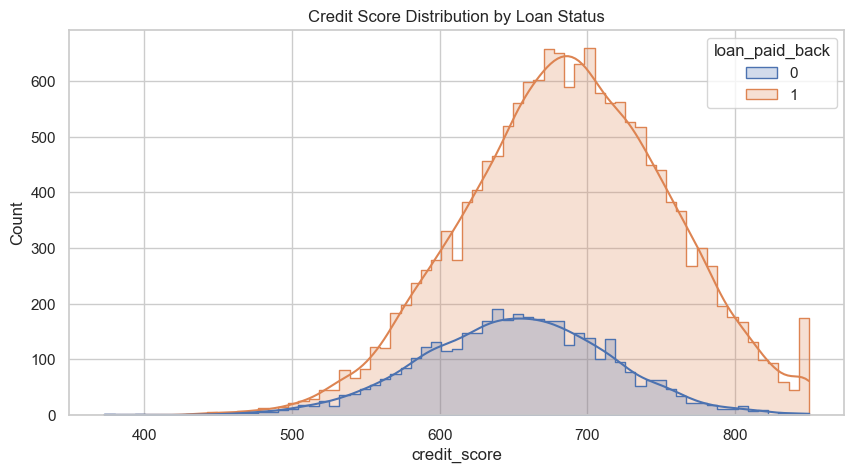

In [14]:
plt.figure(figsize=(10, 5))
sns.histplot(data=df, x='credit_score', hue='loan_paid_back', kde=True, element="step")
plt.title('Credit Score Distribution by Loan Status')
plt.show()

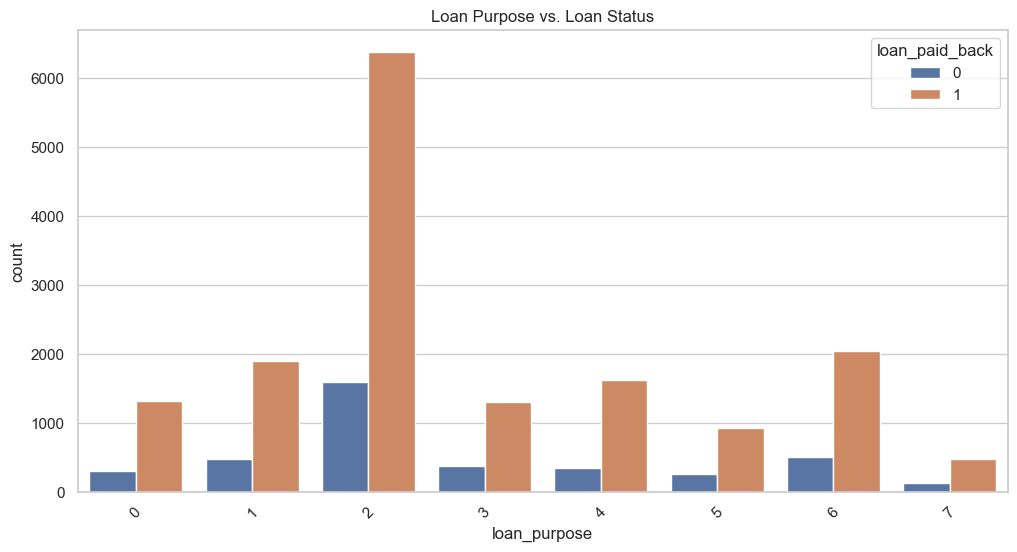

In [15]:
plt.figure(figsize=(12, 6))
sns.countplot(x='loan_purpose', hue='loan_paid_back', data=df)
plt.title('Loan Purpose vs. Loan Status')
plt.xticks(rotation=45)
plt.show()

## Model Training

c:\Users\User\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


--- Logistic Regression Performance ---
Accuracy: 0.8642

Classification Report:
               precision    recall  f1-score   support

           0       0.79      0.46      0.58       818
           1       0.87      0.97      0.92      3182

    accuracy                           0.86      4000
   macro avg       0.83      0.71      0.75      4000
weighted avg       0.86      0.86      0.85      4000



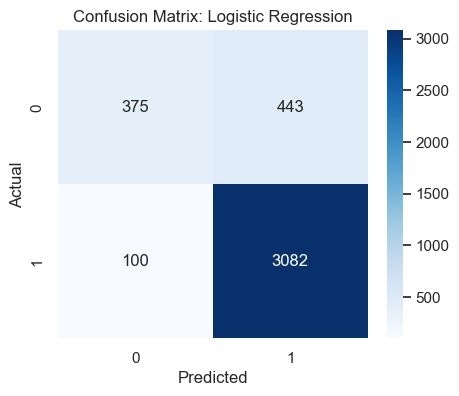

--- Decision Tree Performance ---
Accuracy: 0.8353

Classification Report:
               precision    recall  f1-score   support

           0       0.60      0.60      0.60       818
           1       0.90      0.89      0.90      3182

    accuracy                           0.84      4000
   macro avg       0.75      0.75      0.75      4000
weighted avg       0.84      0.84      0.84      4000



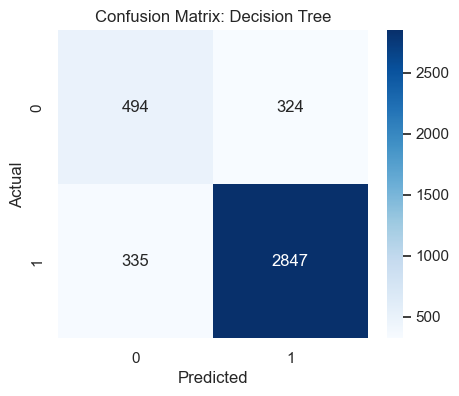

In [16]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Prepare Features (X) and Target (y)
# Drop the target and non-predictive columns if any (like IDs)
X = df.drop('loan_paid_back', axis=1)
y = df['loan_paid_back']

# 2. Split data into Training (80%) and Testing (20%) sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# --- MODEL A: Logistic Regression ---
lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(X_train, y_train)
lr_preds = lr_model.predict(X_test)

# --- MODEL B: Decision Tree ---
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)
dt_preds = dt_model.predict(X_test)

# 3. Evaluation Metrics
def evaluate_model(y_true, y_pred, model_name):
    print(f"--- {model_name} Performance ---")
    print(f"Accuracy: {accuracy_score(y_true, y_pred):.4f}")
    print("\nClassification Report:\n", classification_report(y_true, y_pred))
    
    # Plotting Confusion Matrix
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f'Confusion Matrix: {model_name}')
    plt.ylabel('Actual')
    plt.xlabel('Predicted')
    plt.show()

# Run evaluation
evaluate_model(y_test, lr_preds, "Logistic Regression")
evaluate_model(y_test, dt_preds, "Decision Tree")

## Conclusion and Key Insights

### 1. Model Comparison
In this task, I developed two classification models to predict credit risk: Logistic Regression and a Decision Tree. 
- **Logistic Regression** achieved a higher overall accuracy of **86.42%**.
- **Decision Tree** achieved an accuracy of **83.53%**, but showed a better balance in identifying potential defaulters (higher recall for Class 0).

### 2. Key Predictors
Based on the Exploratory Data Analysis (EDA) and model performance:
- **Credit Score:** Remained the most significant indicator of loan repayment.
- **Annual Income vs. Loan Amount:** Applicants with a lower debt-to-income ratio were significantly more likely to be classified as low-risk.

### 3. Business Recommendation
For a financial institution, the cost of a "False Negative" (predicting someone will pay back when they actually default) is very high. While Logistic Regression is more accurate overall, the **Decision Tree** might be safer for risk-averse lending because it identifies a higher percentage of actual defaults.

### 4. Future Improvements
To improve the model, we could:
- Use **Random Forest** to reduce the overfitting seen in the Decision Tree.
- Apply **SMOTE (Oversampling)** to handle the class imbalance between people who pay back and those who default.